Decision Tree

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


Load the dataset

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)

print("Feature names:", iris.feature_names)
print("Classes:", iris.target_names)


X shape: (150, 4)
y shape: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


Train/test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 120
Testing samples: 30


Entropy

In [5]:
def entropy(y):
    """
    Calculate entropy of a set of class labels.
    """

    if len(y) == 0:
        return 0

    # Count occurrences of each class
    _, counts = np.unique(y, return_counts=True)

    # Convert counts into probabilities
    probabilities = counts / len(y)

    # Calculate entropy
    entropy_value = -np.sum(
        probabilities * np.log2(probabilities)
    )

    return entropy_value


Test Entropy

In [6]:
print("Entropy of [0, 0, 0, 0]:", entropy(np.array([0, 0, 0, 0])))

print("Entropy of [0, 1, 0, 1]:", entropy(np.array([0, 1, 0, 1])))

print("Entropy of [0, 1, 2]:", entropy(np.array([0, 1, 2])))


Entropy of [0, 0, 0, 0]: -0.0
Entropy of [0, 1, 0, 1]: 1.0
Entropy of [0, 1, 2]: 1.584962500721156


Create Split

In [7]:
def split_dataset(X, y, feature_index, threshold):
    """
    Split dataset into left and right groups.
    """

    left_mask = X[:, feature_index] <= threshold
    right_mask = X[:, feature_index] > threshold

    X_left = X[left_mask]
    y_left = y[left_mask]

    X_right = X[right_mask]
    y_right = y[right_mask]

    return X_left, y_left, X_right, y_right


Information Gain

In [8]:
def information_gain(y, y_left, y_right):
    """
    Calculate information gain from a split.
    """

    parent_entropy = entropy(y)

    n = len(y)
    n_left = len(y_left)
    n_right = len(y_right)

    if n_left == 0 or n_right == 0:
        return 0

    weighted_child_entropy = (
        (n_left / n) * entropy(y_left)
        +
        (n_right / n) * entropy(y_right)
    )

    gain = parent_entropy - weighted_child_entropy

    return gain


Test Split

In [9]:
feature_index = 2
threshold = 2.45

X_left, y_left, X_right, y_right = split_dataset(
    X_train,
    y_train,
    feature_index,
    threshold
)

gain = information_gain(
    y_train,
    y_left,
    y_right
)

print("Left samples:", len(y_left))
print("Right samples:", len(y_right))
print("Information gain:", gain)


Left samples: 40
Right samples: 80
Information gain: 0.9182958340544894


Find best split

In [10]:
def best_split(X, y):
    """
    Find the feature and threshold producing
    the highest information gain.
    """

    best_gain = -1
    best_feature = None
    best_threshold = None

    n_samples, n_features = X.shape

    for feature_index in range(n_features):

        # Possible thresholds
        thresholds = np.unique(X[:, feature_index])

        for threshold in thresholds:

            left_mask = X[:, feature_index] <= threshold
            right_mask = ~left_mask

            y_left = y[left_mask]
            y_right = y[right_mask]

            # Ignore invalid splits
            if len(y_left) == 0 or len(y_right) == 0:
                continue

            gain = information_gain(
                y,
                y_left,
                y_right
            )

            if gain > best_gain:
                best_gain = gain
                best_feature = feature_index
                best_threshold = threshold

    return best_feature, best_threshold, best_gain


Find first split

In [11]:
feature, threshold, gain = best_split(
    X_train,
    y_train
)

print("Best feature:", feature)
print("Feature name:", iris.feature_names[feature])
print("Best threshold:", threshold)
print("Information gain:", gain)


Best feature: 2
Feature name: petal length (cm)
Best threshold: 1.9
Information gain: 0.9182958340544894


Create Tree Node

In [12]:
class Node:

    def __init__(
        self,
        feature=None,
        threshold=None,
        left=None,
        right=None,
        value=None
    ):
        self.feature = feature
        self.threshold = threshold

        self.left = left
        self.right = right

        # value is used for leaf nodes
        self.value = value

    def is_leaf(self):
        return self.value is not None


Create Decision Tree

In [13]:
class DecisionTreeFromScratch:

    def __init__(
        self,
        max_depth=5,
        min_samples_split=2
    ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):

        n_samples = len(y)

        # Stopping conditions
        if (
            depth >= self.max_depth
            or n_samples < self.min_samples_split
            or len(np.unique(y)) == 1
        ):
            leaf_value = self._most_common_class(y)
            return Node(value=leaf_value)

        # Find best split
        feature, threshold, gain = best_split(X, y)

        # If no useful split exists
        if feature is None or gain <= 0:
            leaf_value = self._most_common_class(y)
            return Node(value=leaf_value)

        # Split dataset
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        X_left = X[left_mask]
        y_left = y[left_mask]

        X_right = X[right_mask]
        y_right = y[right_mask]

        # Recursively build children
        left_child = self._build_tree(
            X_left,
            y_left,
            depth + 1
        )

        right_child = self._build_tree(
            X_right,
            y_right,
            depth + 1
        )

        return Node(
            feature=feature,
            threshold=threshold,
            left=left_child,
            right=right_child
        )

    def _most_common_class(self, y):
        values, counts = np.unique(
            y,
            return_counts=True
        )

        return values[np.argmax(counts)]


Train Tree

In [14]:
model = DecisionTreeFromScratch(
    max_depth=3
)

model.fit(
    X_train,
    y_train
)

print("Training completed!")


Training completed!


Prediction for one sample

In [16]:
class DecisionTreeFromScratch:

    def __init__(
        self,
        max_depth=5,
        min_samples_split=2
    ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):

        n_samples = len(y)

        if (
            depth >= self.max_depth
            or n_samples < self.min_samples_split
            or len(np.unique(y)) == 1
        ):
            return Node(value=self._most_common_class(y))

        feature, threshold, gain = best_split(X, y)

        if feature is None or gain <= 0:
            return Node(value=self._most_common_class(y))

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        left_child = self._build_tree(
            X[left_mask],
            y[left_mask],
            depth + 1
        )

        right_child = self._build_tree(
            X[right_mask],
            y[right_mask],
            depth + 1
        )

        return Node(
            feature=feature,
            threshold=threshold,
            left=left_child,
            right=right_child
        )

    def _most_common_class(self, y):
        values, counts = np.unique(
            y,
            return_counts=True
        )

        return values[np.argmax(counts)]

    def _predict_one(self, x, node):

        # Leaf node
        if node.is_leaf():
            return node.value

        # Follow left/right branch
        if x[node.feature] <= node.threshold:
            return self._predict_one(
                x,
                node.left
            )
        else:
            return self._predict_one(
                x,
                node.right
            )

    def predict(self, X):

        return np.array([
            self._predict_one(x, self.root)
            for x in X
        ])


Make Predictions

In [17]:
model = DecisionTreeFromScratch(
    max_depth=3
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

print("\nActual:")
print(y_test)


Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]

Actual:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


Calculate Accuracy

In [18]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Our Decision Tree Accuracy:", accuracy)


Our Decision Tree Accuracy: 0.9666666666666667


Classification Report

In [19]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Compare with SkLearn

In [20]:
sklearn_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

sklearn_model.fit(
    X_train,
    y_train
)

sklearn_pred = sklearn_model.predict(
    X_test
)

sklearn_accuracy = accuracy_score(
    y_test,
    sklearn_pred
)

print("Our model accuracy:     ", accuracy)
print("sklearn model accuracy:", sklearn_accuracy)


Our model accuracy:      0.9666666666666667
sklearn model accuracy: 0.9666666666666667


Visualise Iris Data

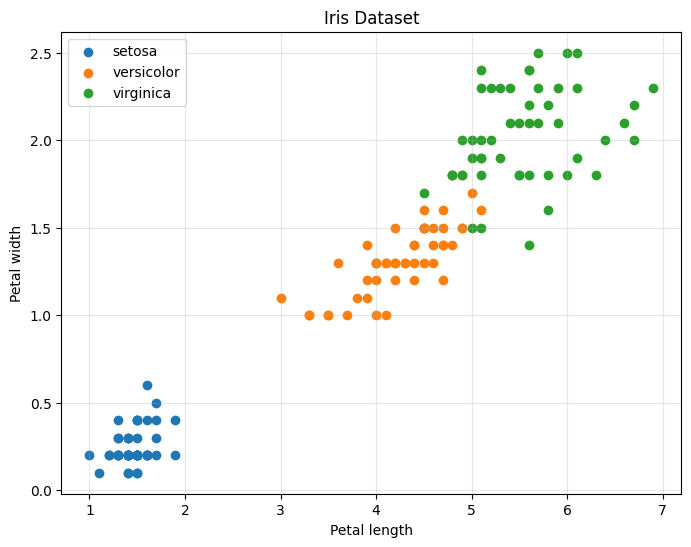

In [21]:
plt.figure(figsize=(8, 6))

for class_id, class_name in enumerate(iris.target_names):

    mask = y == class_id

    plt.scatter(
        X[mask, 2],
        X[mask, 3],
        label=class_name
    )

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("Iris Dataset")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


Visualise SkLearn Tree

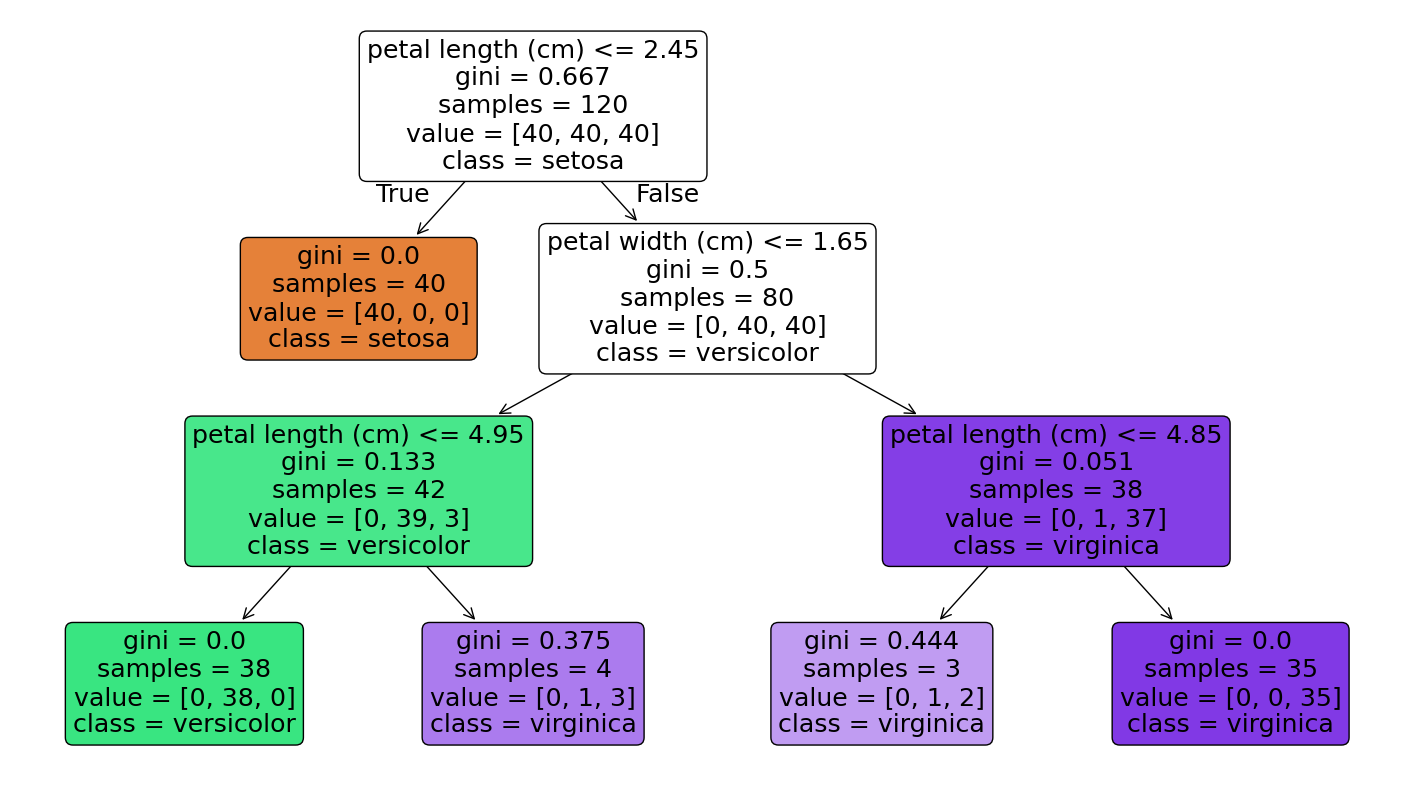

In [22]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    sklearn_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

plt.show()
